## **Library Importing**

In [ ]:
from __future__ import annotations

# ===== Standard Library =====
import re
import warnings
import pickle

# ===== Core Data =====
import numpy as np
import pandas as pd

pd.set_option("display.float_format", "{:,.0f}".format)  # tanpa desimal
warnings.filterwarnings("ignore")

# ===== Scientific / Optimization =====
import scipy
import numba
import ortools

# ===== Visualization =====
import matplotlib.pyplot as plt
import seaborn as sns
import math
from matplotlib.ticker import ScalarFormatter

## Data Preparation

### **Data Preparation - Load Dataset**

In [ ]:
path = r"/content/toyota(in).csv"

In [ ]:
df = pd.read_csv(path,sep=',',engine='python')

#### **Check Columns, Rows, Data Types**

In [ ]:
df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,GT86,2016,16000,Manual,24089,Petrol,265,36,2
1,GT86,2017,15995,Manual,18615,Petrol,145,36,2
2,GT86,2015,13998,Manual,27469,Petrol,265,36,2
3,GT86,2017,18998,Manual,14736,Petrol,150,36,2
4,GT86,2017,17498,Manual,36284,Petrol,145,36,2


In [ ]:
print("Rows, Columns:", df.shape)
print("\nColumns:", list(df.columns))
print("\nData Type:", list(df.dtypes))

Rows, Columns: (6738, 9)

Columns: ['model', 'year', 'price', 'transmission', 'mileage', 'fuelType', 'tax', 'mpg', 'engineSize']

Data Type: [dtype('O'), dtype('int64'), dtype('int64'), dtype('O'), dtype('int64'), dtype('O'), dtype('int64'), dtype('float64'), dtype('float64')]


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6738 entries, 0 to 6737
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         6738 non-null   object 
 1   year          6738 non-null   int64  
 2   price         6738 non-null   int64  
 3   transmission  6738 non-null   object 
 4   mileage       6738 non-null   int64  
 5   fuelType      6738 non-null   object 
 6   tax           6738 non-null   int64  
 7   mpg           6738 non-null   float64
 8   engineSize    6738 non-null   float64
dtypes: float64(2), int64(4), object(3)
memory usage: 473.9+ KB


In [ ]:
df_copy = df.copy()

## **Exploratory Data Analysis (EDA)**

In [ ]:
df_copy.describe()

,year,price,mileage,tax,mpg,engineSize
count,"6,699","6,699","6,699","6,699","6,699","6,699"
mean,"2,017","12,530","22,890",95,63,1
std,2,"6,359","19,109",74,16,0
min,"1,998",850,2,0,3,0
25%,"2,016","8,266","9,488",0,55,1
50%,"2,017","10,798","18,571",135,63,2
75%,"2,018","14,995","31,060",145,71,2
max,"2,020","59,995","174,419",565,235,4


#### **EDA - NULL Values**

##### Key Takeways

*   There is no NULL Value in this Toyota(in) dataset
*   So, we can skip the step of handling missing value



In [ ]:
df_copy.isnull().sum().sort_values(ascending=False)

,0
model,0
year,0
price,0
transmission,0
mileage,0
fuelType,0
tax,0
mpg,0
engineSize,0


#### **EDA - Remove Duplicate**

##### Key Takeaways


*   There are 39 rows duplicate in Toyota(in) dataset
*   So, we should drop the rows



In [ ]:
## Check Total Duplicate Rows
dup_count = df_copy.duplicated().sum()
print("Total duplicate rows:", dup_count)

Total duplicate rows: 0


In [ ]:
df_copy.drop_duplicates(inplace=True)

In [ ]:
## Check Duplicates after dropped
df_copy.duplicated().sum()

np.int64(0)

In [ ]:
print("After drop_duplicates, shape:", df_copy.shape)

After drop_duplicates, shape: (6699, 9)


#### **EDA - Check Distribution**


In [ ]:
## Check list of numerical columns
list_num = df_copy.select_dtypes(exclude=['object','category']).columns.to_list()
len(list_num)

6

#### Distribusi **Numerical**

 ##### Key Takeways

 1. **Year Distribution**
    - Most vehicles are concentrated between 2015–2020.
    - Very few older vehicles (<2010) are present.
    → Dataset is heavily skewed toward newer cars.

 2. **Price Distribution**
    - Right-skewed distribution (long tail on high prices).
    - Majority of vehicles cluster in lower-to-mid price range.
    → A small number of premium vehicles drive extreme high values.

 3. **Mileage Distribution**
    - Strong right skew.
    - Most vehicles have relatively low to moderate mileage.
    - Few vehicles exceed very high mileage (>120k).
    → Indicates typical resale inventory rather than heavily used cars.

 4. **Tax Distribution**
    - Appears multi-modal (multiple peaks).
    - Clusters around specific tax bands.
    → Likely reflects predefined tax brackets or engine categories.

 5. **MPG Distribution**
    - Concentrated mostly between 40–80 MPG.
    - Few extreme values at very high MPG.
    → Most vehicles fall into standard fuel efficiency ranges.

 6. **Engine Size Distribution**
    - Most vehicles fall between 1.0–2.0 engine size.
    - Very few vehicles above 3.0.
    → Dataset dominated by small to mid-sized engines.

 7. **Overall Observation**
    - Several variables (price, mileage) show strong right skewness.
    - Transformations (e.g., log scaling) may improve modeling performance.
    - Engine size and year appear relatively concentrated,
      while price and mileage show high variability.

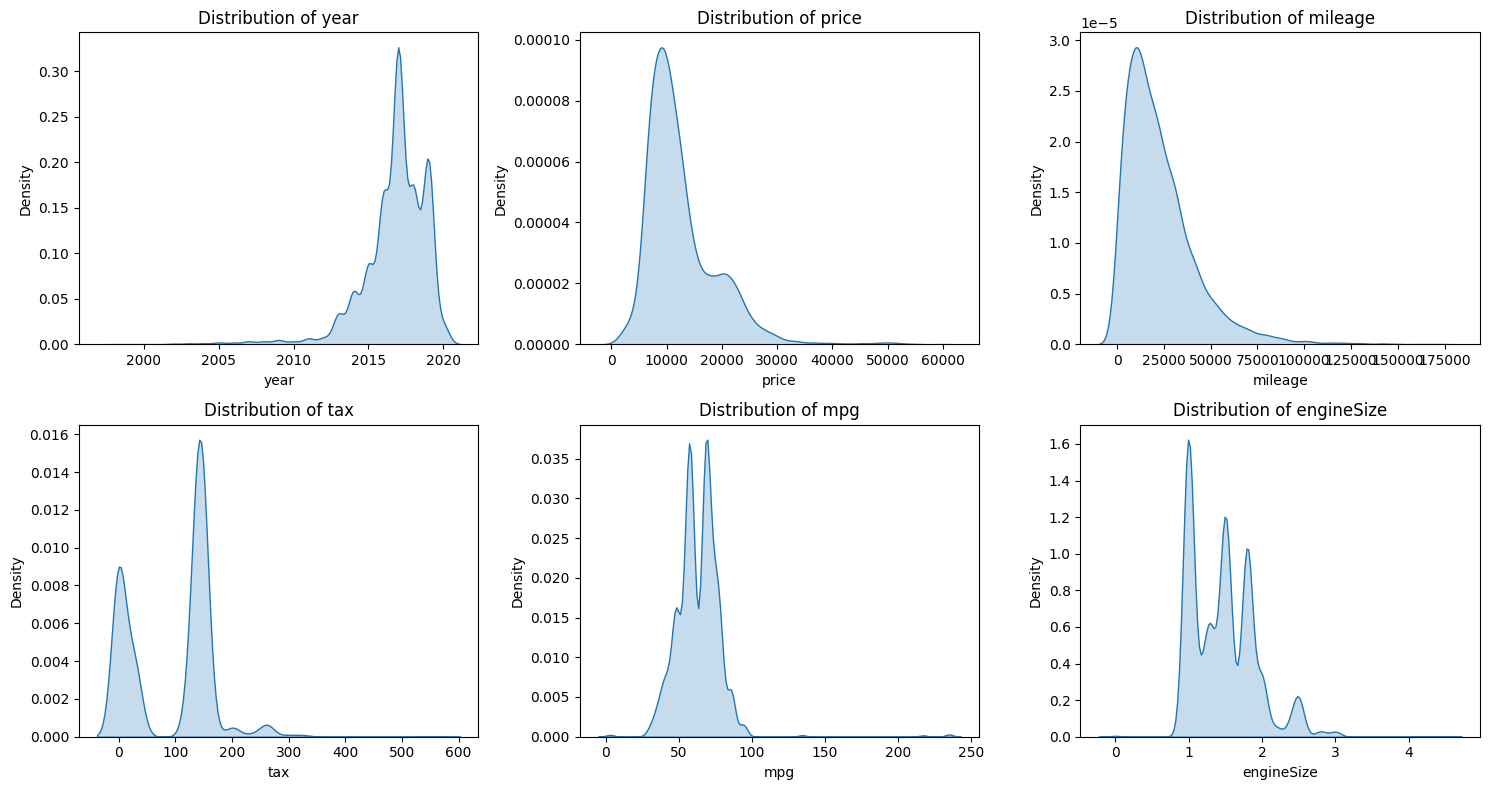

In [ ]:
valid_cols = [
    c for c in list_num
    if c in df_copy.columns
    and df_copy[c].dtype.kind in "if"          # int/float
    and df_copy[c].notna().any()               # ada value non-null
]

# drop konstan value
valid_cols = [c for c in valid_cols if df_copy[c].nunique(dropna=True) > 1]

# Layout subplot
n_cols = 3
n_rows = math.ceil(len(valid_cols) / n_cols) if len(valid_cols) > 0 else 1

plt.figure(figsize=(15, 4 * n_rows))
n = 0

for i in valid_cols:
    n += 1
    plt.subplot(n_rows, n_cols, n)

    sns.kdeplot(
        data=df_copy,
        x=i,
        fill=True,
        common_norm=False
    )

    ax = plt.gca()
    ax.xaxis.set_major_formatter(ScalarFormatter())
    ax.ticklabel_format(style="plain", axis="x")

    plt.title(f"Distribution of {i}")
    plt.xlabel(i)
    plt.ylabel("Density")

plt.tight_layout()
plt.show()

#### Distribusi Categorical

In [ ]:
list_cat = df_copy.select_dtypes(include=["object"]).columns.tolist()
print("Categorical columns:", list_cat)

Categorical columns: ['model', 'transmission', 'fuelType']


In [ ]:
# Cek jumlah kategori & top value
for col in list_cat:
    print("\n---", col, "---")
    print("Unique values:", df[col].nunique())
    print(df[col].value_counts().head(10))


--- model ---
Unique values: 18
model
Yaris      2122
Aygo       1961
Auris       712
C-HR        479
RAV4        473
Corolla     267
Prius       232
Avensis     115
Verso       114
Hilux        86
Name: count, dtype: int64

--- transmission ---
Unique values: 4
transmission
Manual       3826
Automatic    2657
Semi-Auto     254
Other           1
Name: count, dtype: int64

--- fuelType ---
Unique values: 4
fuelType
Petrol    4087
Hybrid    2043
Diesel     503
Other      105
Name: count, dtype: int64


## **EDA - Sanity Check Numerical Feature**

### EDA - **Relationships ( Price VS Year)**

### Key Takeways

1. There is a clear upward trend in price over time. → **Newer products tend to have higher average prices.**

2. The price increase becomes noticeably steeper after around 2014.→ **This suggests accelerated price growth in recent years.**

3. Price variation widens in more recent years. → **The price range becomes larger, indicating both low-end and premium segments.**

4. Several outliers are present (very high prices in certain years). → These could **represent premium models, special editions, or potential anomalies**.

5. In earlier years (< 2010), prices are relatively lower and more stable. → The **market appears more homogeneous** compared to recent years.

6. Visually, there is a strong **positive relationship between year and price** → **Year** is **likely an important predictor variable for price**.

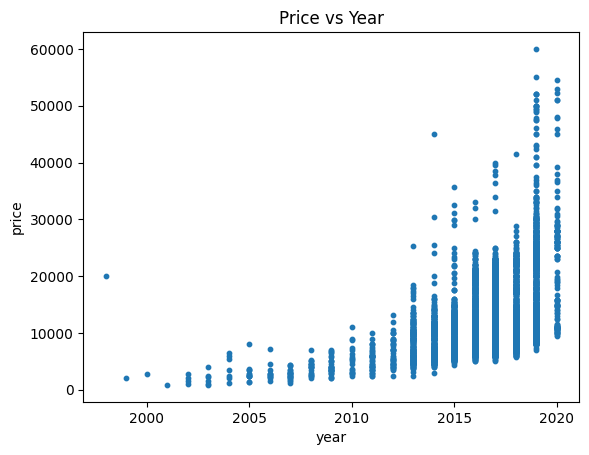

In [ ]:
plt.figure()
plt.scatter(df_copy["year"], df_copy["price"], s=10)
plt.title("Price vs Year")
plt.xlabel("year")
plt.ylabel("price")
plt.show()

### <h2>Strategic Insights & Intent Signals (Price vs Year)</h2>

<h2>Strategic Insights Summary</h2>

<table border="1" cellpadding="8" cellspacing="0">
  <tr>
    <th>Category</th>
    <th>Observation</th>
    <th>Interpretation</th>
    <th>Business Implication</th>
  </tr>

  <!-- Fuel Type -->
  <tr>
    <td><b>Fuel Type</b></td>
    <td>Diesel vehicles show higher price ceilings than Petrol.</td>
    <td>Diesel acts as a premium/resale-strength signal.</td>
    <td>Route Diesel-heavy newer cars to <b>Premium desk</b>.</td>
  </tr>

  <tr>
    <td><b>Fuel Type</b></td>
    <td>Hybrid prices trend higher in recent years.</td>
    <td>Strong demand for eco-efficient vehicles.</td>
    <td>Use Hybrid as primary signal for <b>Eco desk</b>.</td>
  </tr>

  <tr>
    <td><b>Fuel Type</b></td>
    <td>Petrol dominates lower-to-mid price bands.</td>
    <td>Mass-market positioning.</td>
    <td>Combine with Manual + Older year for <b>Budget desk</b>.</td>
  </tr>

  <!-- Transmission -->
  <tr>
    <td><b>Transmission</b></td>
    <td>Automatic vehicles consistently priced higher than Manual.</td>
    <td>Strong premium intent signal.</td>
    <td>Automatic → prioritize for <b>Premium routing</b>.</td>
  </tr>

  <tr>
    <td><b>Transmission</b></td>
    <td>Manual vehicles cluster in lower price bands.</td>
    <td>Budget positioning.</td>
    <td>Manual + Older year → <b>Budget desk</b>.</td>
  </tr>

  <!-- Model -->
  <tr>
    <td><b>Model</b></td>
    <td>RAV4 shows highest price band across years.</td>
    <td>Premium SUV positioning.</td>
    <td>Strong <b>Premium segment</b> indicator.</td>
  </tr>

  <tr>
    <td><b>Model</b></td>
    <td>C-HR &amp; Auris sit in mid-to-upper band.</td>
    <td>Higher trim/crossover positioning.</td>
    <td>Consider Premium or upper-mid segment.</td>
  </tr>

  <tr>
    <td><b>Model</b></td>
    <td>Yaris &amp; Aygo dominate lower price band.</td>
    <td>Entry-level segment.</td>
    <td>Primary candidates for <b>Budget desk</b>.</td>
  </tr>

  <!-- Year -->
  <tr>
    <td><b>Year</b></td>
    <td>Newer year consistently correlates with higher price.</td>
    <td>Strongest universal driver.</td>
    <td>Use Year as base filtering logic before segmentation.</td>
  </tr>
</table>

<br/>

<h2>Feature Strength Ranking (Visual Hypothesis)</h2>

<table border="1" cellpadding="8" cellspacing="0">
  <tr>
    <th>Rank</th>
    <th>Feature</th>
    <th>Reason</th>
  </tr>
  <tr>
    <td>1</td>
    <td><b>Year</b></td>
    <td>Clear consistent upward trend across all segments.</td>
  </tr>
  <tr>
    <td>2</td>
    <td><b>Model</b></td>
    <td>Strong separation of price tiers.</td>
  </tr>
  <tr>
    <td>3</td>
    <td><b>Transmission</b></td>
    <td>Automatic vs Manual shows visible premium gap.</td>
  </tr>
  <tr>
    <td>4</td>
    <td><b>Fuel Type</b></td>
    <td>Diesel/Hybrid show premium behavior.</td>
  </tr>
  <tr>
    <td>5</td>
    <td><b>Mileage</b></td>
    <td>Negative correlation, strengthens prediction when combined with Year.</td>
  </tr>
</table>

<br/>

<h2>Strategic Routing Logic (High-Level)</h2>

<table border="1" cellpadding="8" cellspacing="0">
  <tr>
    <th>Desk</th>
    <th>Primary Signals</th>
  </tr>
  <tr>
    <td><b>Premium</b></td>
    <td>Newer Year + Automatic/Semi-Auto + Diesel/Hybrid + SUV models (RAV4, C-HR)</td>
  </tr>
  <tr>
    <td><b>Budget</b></td>
    <td>Older Year + Manual + Petrol + Entry models (Aygo, Yaris)</td>
  </tr>
  <tr>
    <td><b>Eco</b></td>
    <td>Hybrid + High MPG + Smaller engine size</td>
  </tr>
</table>

<br/>

<h2>Intent Signal Analysis – Price vs Year</h2>

<table border="1" cellpadding="8" cellspacing="0">
  <tr>
    <th>Observation (Visual Evidence)</th>
    <th>Interpretation</th>
    <th>Intent Signal Strength</th>
    <th>Business Implication</th>
  </tr>

  <tr>
    <td>Strong upward trend: newer vehicles consistently priced higher.</td>
    <td>Year is a dominant structural driver of resale value.</td>
    <td><b>Very Strong</b></td>
    <td>Use Year as primary baseline variable in pricing and routing logic.</td>
  </tr>

  <tr>
    <td>Steeper price increase after ~2014.</td>
    <td>Recent models experience accelerated valuation growth.</td>
    <td><b>Strong</b></td>
    <td>Vehicles 2015+ should be evaluated for Premium desk first.</td>
  </tr>

  <tr>
    <td>Older vehicles cluster tightly in lower price bands.</td>
    <td>Lower ceiling regardless of other features.</td>
    <td><b>Strong (for Budget)</b></td>
    <td>Pre-2012 vehicles are strong candidates for Budget routing.</td>
  </tr>

  <tr>
    <td>Newer vehicles show wider price dispersion.</td>
    <td>Other features (model, transmission, fuel type) amplify price within new-year group.</td>
    <td><b>Interaction Signal</b></td>
    <td>Combine Year + Model/Transmission for better segmentation accuracy.</td>
  </tr>

  <tr>
    <td>All models show consistent upward pattern across years.</td>
    <td>Year effect is universal across segments.</td>
    <td><b>Universal Intent Signal</b></td>
    <td>Year should be weighted heavily in predictive modeling.</td>
  </tr>
</table>

<br/>

<h2>Strategic Interpretation – Year as an Intent Signal</h2>

<table border="1" cellpadding="8" cellspacing="0">
  <tr>
    <th>Intent Type</th>
    <th>Signal Pattern</th>
    <th>Operational Use</th>
  </tr>

  <tr>
    <td><b>High Resale Value Intent</b></td>
    <td>Newer Year (especially 2015+)</td>
    <td>Prioritize for Premium desk and higher marketing visibility.</td>
  </tr>

  <tr>
    <td><b>Fast Sale Intent</b></td>
    <td>Mid-age vehicles (2014–2017) priced competitively</td>
    <td>These may move faster due to affordability + acceptable recency.</td>
  </tr>

  <tr>
    <td><b>Budget Market Intent</b></td>
    <td>Older Year + Lower price clustering</td>
    <td>Route directly to Budget desk to reduce handling time.</td>
  </tr>
</table>

<br/>

<h3>Analytical Conclusion</h3>
<p>
Based on visual evidence, <b>Year is the strongest standalone intent signal</b> in the dataset.
It consistently explains structural price shifts across fuel types, transmission types, and models.
Other features refine price positioning, but Year establishes the baseline valuation band.
</p>

#### EDA - **Relationships ( Price VS Year) by Fuel Type**

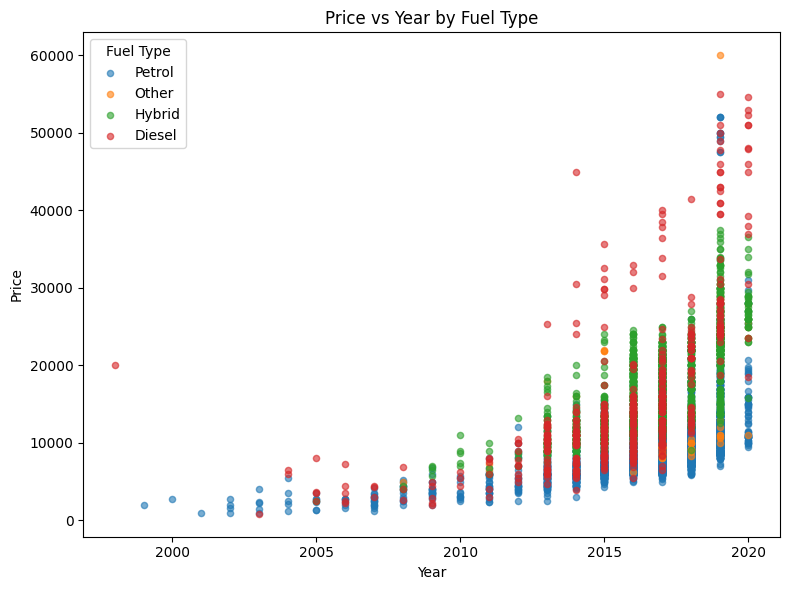

In [ ]:
plt.figure(figsize=(8,6))

for fuel in df_copy["fuelType"].unique():
    subset = df_copy[df_copy["fuelType"] == fuel]
    plt.scatter(subset["year"], subset["price"], s=20, label=fuel, alpha=0.6)

plt.title("Price vs Year by Fuel Type")
plt.xlabel("Year")
plt.ylabel("Price")
plt.legend(title="Fuel Type")
plt.tight_layout()
plt.show()

#### EDA - **Relationships ( Price VS Year) by Transmission**

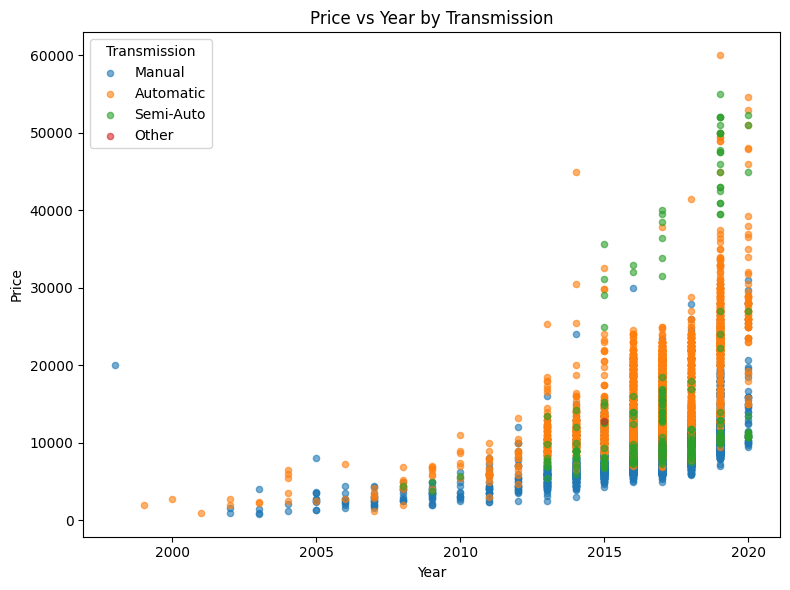

In [ ]:
plt.figure(figsize=(8,6))

for trans in df_copy["transmission"].unique():
    subset = df_copy[df_copy["transmission"] == trans]
    plt.scatter(subset["year"], subset["price"], s=20, label=trans, alpha=0.6)

plt.title("Price vs Year by Transmission")
plt.xlabel("Year")
plt.ylabel("Price")
plt.legend(title="Transmission")
plt.tight_layout()
plt.show()

#### EDA - **Relationships ( Price VS Year) for TOP 5 Model**

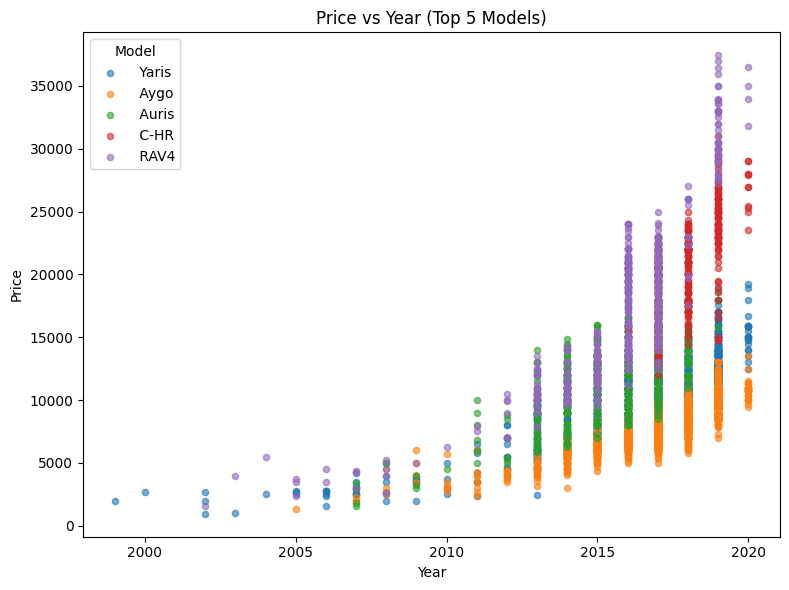

In [ ]:
top_models = df_copy["model"].value_counts().head(5).index

plt.figure(figsize=(8,6))

for model in top_models:
    subset = df_copy[df_copy["model"] == model]
    plt.scatter(subset["year"], subset["price"], s=20, label=model, alpha=0.6)

plt.title("Price vs Year (Top 5 Models)")
plt.xlabel("Year")
plt.ylabel("Price")
plt.legend(title="Model")
plt.tight_layout()
plt.show()

### EDA - **Relationships ( Price VS Milage)**

 ### Key Takeways
 1. There is a clear negative relationship between mileage and price.
    → As **mileage increases, price generally decreases**.

 2. The price drop appears steeper at lower mileage levels.
    → Vehicles **lose value more rapidly during the early mileage range**.

 3. Price dispersion is higher at low mileage.
    → Low-mileage vehicles include both **mid-range and premium-priced units**.

 4. At high mileage levels (> 100,000), prices cluster at lower values.
    → **High-mileage vehicles tend to have consistently lower prices**.

 5. Several outliers exist (high price with high mileage or very low price points).
    → These may **represent premium brands, special conditions, or data anomalies**.

 6. The relationship appears non-linear.
    → **Depreciation may follow a diminishing curve** rather than a simple linear trend.

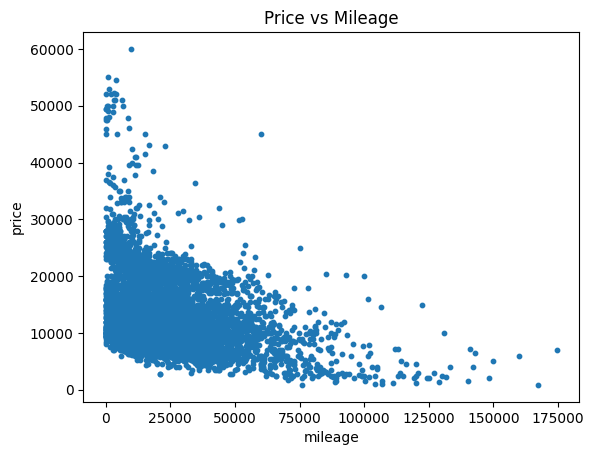

In [ ]:
plt.figure()
plt.scatter(df_copy["mileage"], df_copy["price"], s=10)
plt.title("Price vs Mileage")
plt.xlabel("mileage")
plt.ylabel("price")
plt.show()

###<h2>Strategic Insights – Price vs Mileage Analysis</h2>

<h2>Price vs Mileage by Fuel Type</h2>

<table border="1" cellpadding="8" cellspacing="0">
  <tr>
    <th>Observation</th>
    <th>Interpretation</th>
    <th>Intent Signal Strength</th>
    <th>Business Implication</th>
  </tr>

  <tr>
    <td>Clear negative relationship between mileage and price across all fuel types.</td>
    <td>Mileage is a structural depreciation driver.</td>
    <td><b>Very Strong</b></td>
    <td>Use Mileage as core pricing baseline variable.</td>
  </tr>

  <tr>
    <td>Diesel vehicles maintain higher prices even at moderate mileage.</td>
    <td>Diesel shows stronger resale retention.</td>
    <td><b>Strong</b></td>
    <td>High-mileage Diesel may still qualify for Premium desk.</td>
  </tr>

  <tr>
    <td>Hybrid vehicles maintain mid-to-high price band at low mileage.</td>
    <td>Hybrid has strong early-life premium positioning.</td>
    <td><b>Strong (Low Mileage)</b></td>
    <td>Low-mileage Hybrid → prioritize Eco/Premium evaluation.</td>
  </tr>

  <tr>
    <td>Petrol vehicles dominate lower price clusters at higher mileage.</td>
    <td>Petrol resale drops faster at higher usage levels.</td>
    <td><b>Moderate</b></td>
    <td>High-mileage Petrol → strong Budget desk signal.</td>
  </tr>
</table>

<br/>


<h2>Price vs Mileage by Transmission</h2>

<table border="1" cellpadding="8" cellspacing="0">
  <tr>
    <th>Observation</th>
    <th>Interpretation</th>
    <th>Intent Signal Strength</th>
    <th>Business Implication</th>
  </tr>

  <tr>
    <td>Automatic vehicles retain higher prices at similar mileage levels.</td>
    <td>Automatic transmission increases perceived value.</td>
    <td><b>Strong</b></td>
    <td>Automatic + Low Mileage → Premium routing candidate.</td>
  </tr>

  <tr>
    <td>Manual vehicles cluster in lower price range across mileage bands.</td>
    <td>Manual is associated with budget positioning.</td>
    <td><b>Strong (Budget)</b></td>
    <td>Manual + High Mileage → Budget desk.</td>
  </tr>

  <tr>
    <td>Semi-Auto appears mostly in higher price regions.</td>
    <td>Linked to higher trims/performance variants.</td>
    <td><b>Moderate to Strong</b></td>
    <td>Evaluate as Premium unless mileage extremely high.</td>
  </tr>
</table>

<br/>

<h2>Price vs Mileage (Top 5 Models)</h2>

<table border="1" cellpadding="8" cellspacing="0">
  <tr>
    <th>Observation</th>
    <th>Interpretation</th>
    <th>Intent Signal Strength</th>
    <th>Business Implication</th>
  </tr>

  <tr>
    <td>RAV4 maintains highest price across mileage bands.</td>
    <td>Strong premium SUV resale behavior.</td>
    <td><b>Very Strong</b></td>
    <td>RAV4 → Premium desk baseline candidate.</td>
  </tr>

  <tr>
    <td>C-HR shows upper-mid price retention.</td>
    <td>Strong crossover positioning.</td>
    <td><b>Strong</b></td>
    <td>Mid-to-high mileage C-HR may still be Premium.</td>
  </tr>

  <tr>
    <td>Auris sits mid-tier.</td>
    <td>Balanced segment.</td>
    <td><b>Moderate</b></td>
    <td>Requires combination with Year & Transmission.</td>
  </tr>

  <tr>
    <td>Yaris and Aygo dominate lower price band at all mileage levels.</td>
    <td>Entry-level depreciation curve.</td>
    <td><b>Strong (Budget)</b></td>
    <td>High-mileage Yaris/Aygo → Budget routing.</td>
  </tr>
</table>

<br/>

<h2>Intent Signal Analysis – Mileage</h2>

<table border="1" cellpadding="8" cellspacing="0">
  <tr>
    <th>Intent Type</th>
    <th>Signal Pattern</th>
    <th>Operational Use</th>
  </tr>

  <tr>
    <td><b>High Resale Value Intent</b></td>
    <td>Low Mileage (&lt; 30k)</td>
    <td>Strong Premium evaluation candidate.</td>
  </tr>

  <tr>
    <td><b>Fast Sale Intent</b></td>
    <td>Mid Mileage (30k–70k) priced competitively</td>
    <td>Attractive balance between affordability and usage.</td>
  </tr>

  <tr>
    <td><b>Budget Market Intent</b></td>
    <td>High Mileage (&gt; 80k)</td>
    <td>Direct Budget routing to reduce cycle time.</td>
  </tr>
</table>

<br/>

<h3>Analytical Conclusion</h3>
<p>
Mileage is the <b>second strongest standalone intent signal after Year</b>.
It consistently drives price depreciation across fuel types, transmission types, and models.
However, its effect is amplified when combined with premium indicators such as Model and Transmission.
</p>

#### EDA - **Relationships ( Price VS Milage) by Fuel Type**

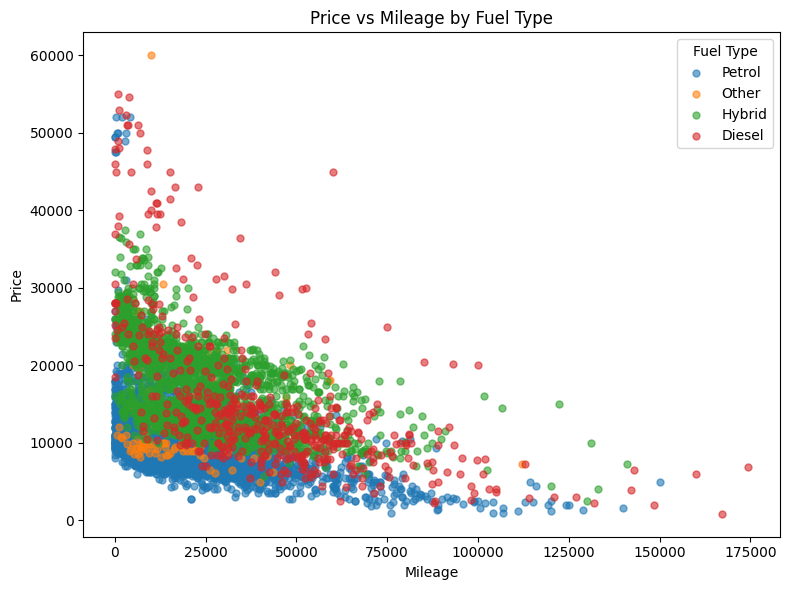

In [ ]:
plt.figure(figsize=(8,6))

for fuel in df_copy["fuelType"].unique():
    subset = df_copy[df_copy["fuelType"] == fuel]
    plt.scatter(
        subset["mileage"],
        subset["price"],
        s=25,
        alpha=0.6,
        label=fuel
    )

plt.title("Price vs Mileage by Fuel Type")
plt.xlabel("Mileage")
plt.ylabel("Price")
plt.legend(title="Fuel Type")
plt.tight_layout()
plt.show()

#### EDA - **Relationships ( Price VS Milage) by Transmission**

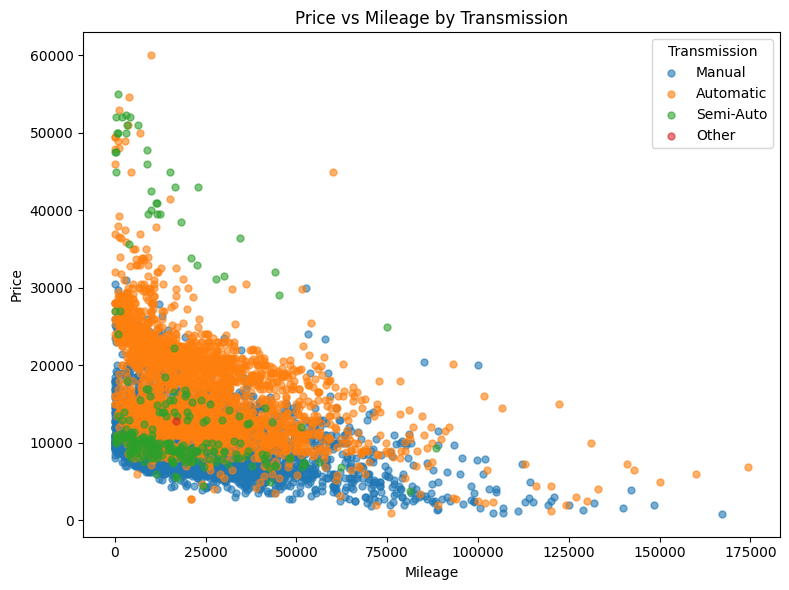

In [ ]:
plt.figure(figsize=(8,6))

for trans in df_copy["transmission"].unique():
    subset = df_copy[df_copy["transmission"] == trans]
    plt.scatter(
        subset["mileage"],
        subset["price"],
        s=25,
        alpha=0.6,
        label=trans
    )

plt.title("Price vs Mileage by Transmission")
plt.xlabel("Mileage")
plt.ylabel("Price")
plt.legend(title="Transmission")
plt.tight_layout()
plt.show()

#### EDA - **Relationships ( Price VS Milage) by Model**

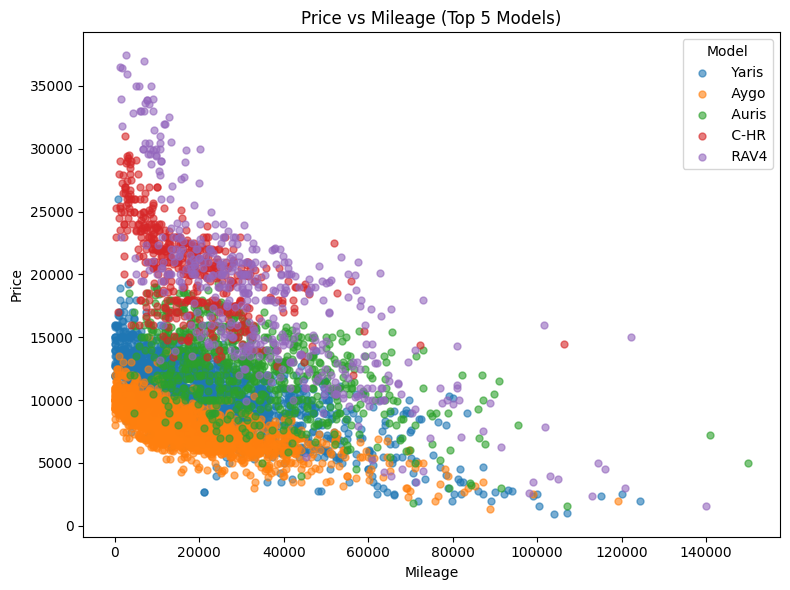

In [ ]:
top_models = df_copy["model"].value_counts().head(5).index

plt.figure(figsize=(8,6))

for model in top_models:
    subset = df_copy[df_copy["model"] == model]
    plt.scatter(
        subset["mileage"],
        subset["price"],
        s=25,
        alpha=0.6,
        label=model
    )

plt.title("Price vs Mileage (Top 5 Models)")
plt.xlabel("Mileage")
plt.ylabel("Price")
plt.legend(title="Model")
plt.tight_layout()
plt.show()

### EDA - **Relationships ( Price VS Tax)**

 ### Key Takeways

 1. There is a general positive relationship between tax and price.
    → Vehicles with **higher tax values tend to have higher prices**.

 2. The relationship is not strictly linear.
    → Some vehicles with **similar tax values have a wide range of prices**.

 3. Mid-range tax levels (around 100–250) show the highest price dispersion.
    → This suggests **mixed vehicle segments within these tax brackets**.

 4. Very low tax values are generally associated with lower-priced vehicles.
    → Likely **representing economy or smaller engine vehicles**.

 5. High tax values (>300) are relatively rare but often linked to higher prices.
    → These may **correspond to larger engines, luxury, or high-performance models**.

 6. Several outliers are present.
    → Some vehicles with **moderate tax levels have unusually high prices, possibly due to brand premium or special features**.

 7. Tax alone may not be a strong standalone predictor of price.
    → It **likely interacts with other variables such as year, engine size, or brand.**

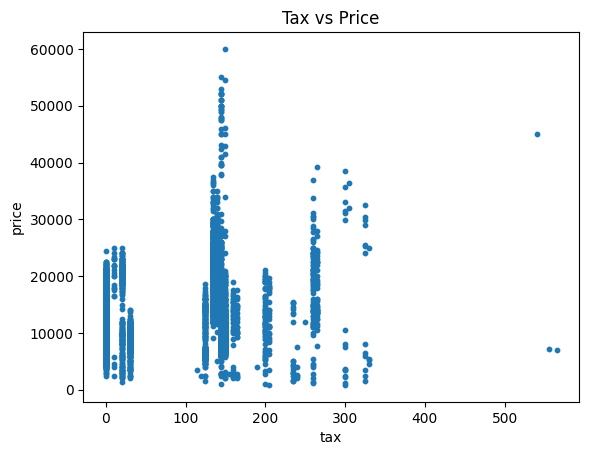

In [ ]:
plt.figure()
plt.scatter(df_copy["tax"], df_copy["price"], s=10)
plt.title("Tax vs Price")
plt.xlabel("tax")
plt.ylabel("price")
plt.show()

###<h2>Strategic Insights – Price vs Tax Analysis</h2>

<h2>Price vs Tax by Fuel Type</h2>

<table border="1" cellpadding="8" cellspacing="0">
  <tr>
    <th>Observation</th>
    <th>Interpretation</th>
    <th>Intent Signal Strength</th>
    <th>Business Implication</th>
  </tr>

  <tr>
    <td>Tax shows clustered bands rather than continuous spread.</td>
    <td>Tax likely reflects predefined engine/emission brackets.</td>
    <td><b>Structural (Segment Indicator)</b></td>
    <td>Use Tax as categorical band, not pure numeric predictor.</td>
  </tr>

  <tr>
    <td>Higher tax bands often align with higher price ceilings.</td>
    <td>Higher tax associated with larger engines or premium vehicles.</td>
    <td><b>Moderate to Strong</b></td>
    <td>High Tax + Newer Year → Premium candidate.</td>
  </tr>

  <tr>
    <td>Diesel vehicles frequently appear in mid-to-high tax bands with higher prices.</td>
    <td>Diesel vehicles often positioned in larger engine segments.</td>
    <td><b>Moderate</b></td>
    <td>Combine Diesel + Tax band for premium filtering.</td>
  </tr>

  <tr>
    <td>Low tax band vehicles cluster in lower price range.</td>
    <td>Small engine / economy segment.</td>
    <td><b>Strong (Budget)</b></td>
    <td>Low Tax + Older Year → Budget desk routing.</td>
  </tr>
</table>

<br/>

<h2>Price vs Tax by Transmission</h2>

<table border="1" cellpadding="8" cellspacing="0">
  <tr>
    <th>Observation</th>
    <th>Interpretation</th>
    <th>Intent Signal Strength</th>
    <th>Business Implication</th>
  </tr>

  <tr>
    <td>Automatic vehicles dominate higher price points within same tax bands.</td>
    <td>Transmission amplifies price within tax segment.</td>
    <td><b>Strong (Interaction)</b></td>
    <td>Automatic + High Tax → Strong Premium signal.</td>
  </tr>

  <tr>
    <td>Manual vehicles cluster at lower prices even in similar tax brackets.</td>
    <td>Manual reduces perceived value premium.</td>
    <td><b>Moderate</b></td>
    <td>Manual + Low/Mid Tax → Budget routing.</td>
  </tr>

  <tr>
    <td>Semi-Auto appears mostly in upper price segments.</td>
    <td>Associated with higher trim/performance models.</td>
    <td><b>Moderate</b></td>
    <td>Flag for Premium unless other signals contradict.</td>
  </tr>
</table>

<br/>

<h2>Price vs Tax (Top 5 Models)</h2>

<table border="1" cellpadding="8" cellspacing="0">
  <tr>
    <th>Observation</th>
    <th>Interpretation</th>
    <th>Intent Signal Strength</th>
    <th>Business Implication</th>
  </tr>

  <tr>
    <td>RAV4 maintains high prices even across varying tax levels.</td>
    <td>Model-level premium effect stronger than tax alone.</td>
    <td><b>Very Strong (Model Effect)</b></td>
    <td>Model may override tax signal for routing.</td>
  </tr>

  <tr>
    <td>C-HR sits consistently above Yaris/Aygo within similar tax bands.</td>
    <td>Segment differentiation beyond tax classification.</td>
    <td><b>Strong</b></td>
    <td>Use Model as primary segment identifier.</td>
  </tr>

  <tr>
    <td>Yaris & Aygo cluster in lower tax and lower price bands.</td>
    <td>Small-engine economy profile.</td>
    <td><b>Strong (Budget)</b></td>
    <td>Low Tax + Entry Model → Budget desk.</td>
  </tr>
</table>

<br/>

<h2>Intent Signal Analysis – Tax</h2>

<table border="1" cellpadding="8" cellspacing="0">
  <tr>
    <th>Intent Type</th>
    <th>Signal Pattern</th>
    <th>Operational Use</th>
  </tr>

  <tr>
    <td><b>High Resale Value Intent</b></td>
    <td>Mid-to-High Tax Band + Automatic + Premium Model</td>
    <td>Evaluate for Premium routing.</td>
  </tr>

  <tr>
    <td><b>Fast Sale Intent</b></td>
    <td>Mid Tax Band (mass segment) priced competitively</td>
    <td>Likely broader buyer demand pool.</td>
  </tr>

  <tr>
    <td><b>Budget Market Intent</b></td>
    <td>Low Tax Band + Manual + Entry Model</td>
    <td>Direct Budget desk assignment.</td>
  </tr>
</table>

<br/>

<h3>Analytical Conclusion</h3>
<p>
Tax is a <b>segment indicator rather than a dominant standalone predictor</b>.
It reflects engine/emission class bands, which influence price indirectly.
Tax becomes meaningful when combined with Model, Transmission, and Year.
Alone, it is weaker than Year or Mileage in predicting resale value.
</p>

#### EDA - **Relationships ( Price VS Tax) by Fuel Type**

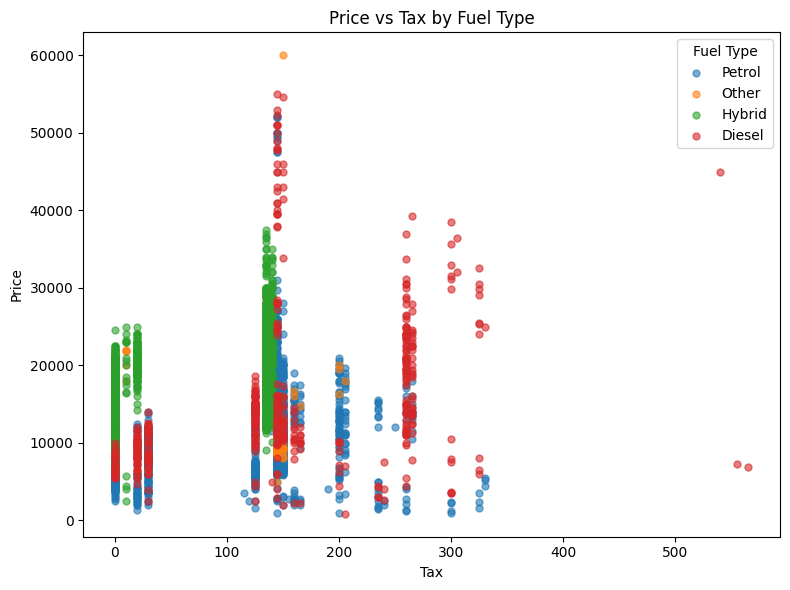

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

for fuel in df_copy["fuelType"].unique():
    subset = df_copy[df_copy["fuelType"] == fuel]
    plt.scatter(
        subset["tax"],
        subset["price"],
        s=25,
        alpha=0.6,
        label=fuel
    )

plt.title("Price vs Tax by Fuel Type")
plt.xlabel("Tax")
plt.ylabel("Price")
plt.legend(title="Fuel Type")
plt.tight_layout()
plt.show()

#### EDA - **Relationships ( Price VS Tax) by Transmission**

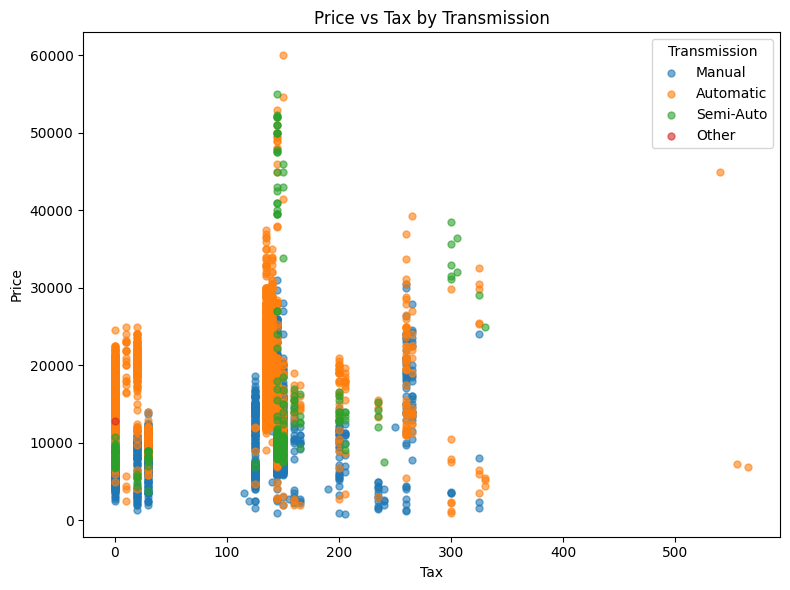

In [ ]:
plt.figure(figsize=(8,6))

for trans in df_copy["transmission"].unique():
    subset = df_copy[df_copy["transmission"] == trans]
    plt.scatter(
        subset["tax"],
        subset["price"],
        s=25,
        alpha=0.6,
        label=trans
    )

plt.title("Price vs Tax by Transmission")
plt.xlabel("Tax")
plt.ylabel("Price")
plt.legend(title="Transmission")
plt.tight_layout()
plt.show()

#### EDA - **Relationships ( Price VS Tax) by Top 5 Model**

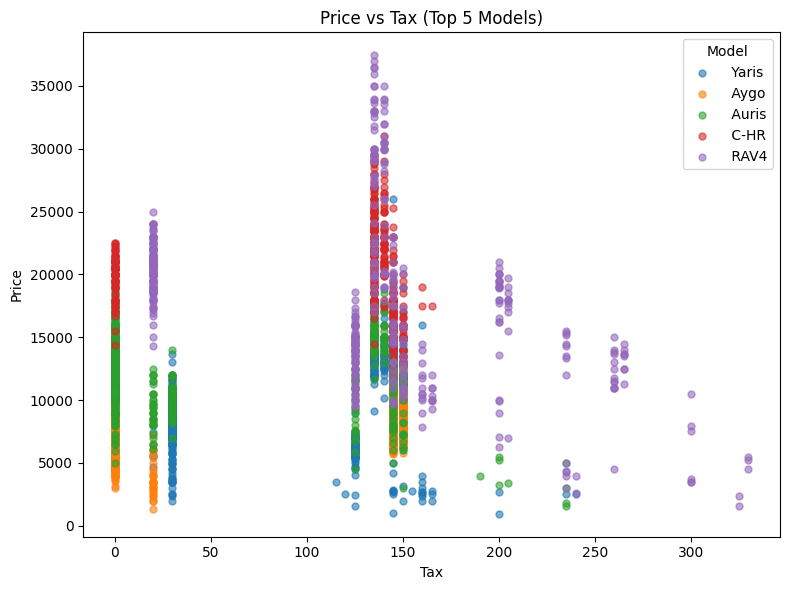

In [ ]:
top_models = df_copy["model"].value_counts().head(5).index

plt.figure(figsize=(8,6))

for model in top_models:
    subset = df_copy[df_copy["model"] == model]
    plt.scatter(
        subset["tax"],
        subset["price"],
        s=25,
        alpha=0.6,
        label=model
    )

plt.title("Price vs Tax (Top 5 Models)")
plt.xlabel("Tax")
plt.ylabel("Price")
plt.legend(title="Model")
plt.tight_layout()
plt.show()

### EDA - **Relationships ( Price VS Engine Size)**

 ### Key Takeways
 1. There is a clear positive relationship between engine size and price.
    → **Vehicles with larger engine sizes generally have higher prices**.

 2. Most vehicles cluster within the mid engine size range (around 100–300).
    → This **likely represents the mainstream market segment.**

 3. Larger engine sizes (>300) are relatively rare but tend to be priced higher.
    → These may **correspond to premium or performance-oriented vehicles.**

 4. Smaller engine sizes (below 150) are generally associated with lower prices.
    → Likely **representing economy or entry-level vehicles.**

 5. Price dispersion increases as engine size increases.
    → **Larger engines may belong to different trims, brands, or luxury categories.**

 6. A few outliers exist (very large engine sizes with very high prices).
    → These **could represent high-performance or specialty vehicles.**

 7. Engine size appears **to be a strong predictor** of price,
    → **especially when combined with other variables such as year and mileage.**

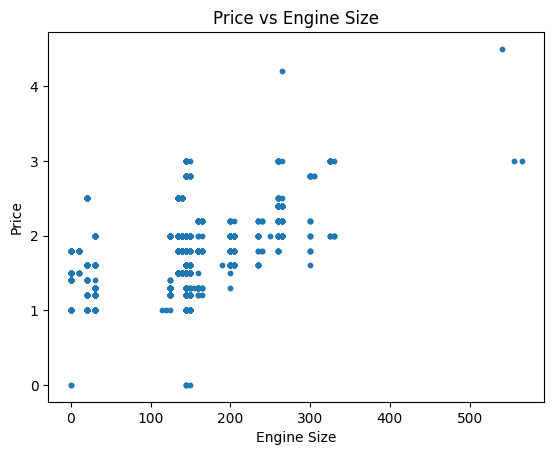

In [ ]:
plt.figure()
plt.scatter(df_copy["tax"], df_copy["engineSize"], s=10)
plt.title("Price vs Engine Size")
plt.xlabel("Engine Size")
plt.ylabel("Price")
plt.show()

### <h2>Strategic Insights – Price vs Engine Size Analysis</h2>

<h2>Price vs Engine Size by Fuel Type</h2>

<table border="1" cellpadding="8" cellspacing="0">
  <tr>
    <th>Observation</th>
    <th>Interpretation</th>
    <th>Intent Signal Strength</th>
    <th>Business Implication</th>
  </tr>

  <tr>
    <td>Clear positive relationship between engine size and price.</td>
    <td>Larger engines correspond to higher vehicle valuation.</td>
    <td><b>Strong</b></td>
    <td>Engine Size is a premium segmentation driver.</td>
  </tr>

  <tr>
    <td>Diesel and Hybrid appear in mid-to-large engine bands with higher prices.</td>
    <td>These fuel types amplify engine-size premium effect.</td>
    <td><b>Moderate to Strong</b></td>
    <td>Combine Engine Size + Fuel Type for Premium routing logic.</td>
  </tr>

  <tr>
    <td>Small engine sizes (1.0–1.3) cluster in lower price range.</td>
    <td>Economy/entry-level positioning.</td>
    <td><b>Strong (Budget)</b></td>
    <td>Small Engine + Manual → Budget desk candidate.</td>
  </tr>
</table>

<br/>

<h2>Price vs Engine Size by Transmission</h2>

<table border="1" cellpadding="8" cellspacing="0">
  <tr>
    <th>Observation</th>
    <th>Interpretation</th>
    <th>Intent Signal Strength</th>
    <th>Business Implication</th>
  </tr>

  <tr>
    <td>Automatic vehicles dominate higher price levels within same engine size.</td>
    <td>Transmission amplifies engine-size premium effect.</td>
    <td><b>Strong (Interaction)</b></td>
    <td>Large Engine + Automatic → Premium desk.</td>
  </tr>

  <tr>
    <td>Manual vehicles remain lower priced even at larger engine sizes.</td>
    <td>Manual reduces perceived premium positioning.</td>
    <td><b>Moderate</b></td>
    <td>Manual + Mid Engine → Evaluate carefully before Premium routing.</td>
  </tr>

  <tr>
    <td>Semi-Auto appears in higher price segments.</td>
    <td>Often linked to performance or higher trim levels.</td>
    <td><b>Moderate</b></td>
    <td>Flag as potential Premium indicator.</td>
  </tr>
</table>

<br/>

<h2>Price vs Engine Size (Top 5 Models)</h2>

<table border="1" cellpadding="8" cellspacing="0">
  <tr>
    <th>Observation</th>
    <th>Interpretation</th>
    <th>Intent Signal Strength</th>
    <th>Business Implication</th>
  </tr>

  <tr>
    <td>RAV4 consistently priced highest across engine sizes.</td>
    <td>Model premium effect stronger than engine size alone.</td>
    <td><b>Very Strong (Model Effect)</b></td>
    <td>Model may override engine size for routing decisions.</td>
  </tr>

  <tr>
    <td>C-HR and Auris occupy mid-to-upper price bands.</td>
    <td>Balanced engine-size positioning with segment premium.</td>
    <td><b>Strong</b></td>
    <td>Use Model + Engine Size interaction for segmentation.</td>
  </tr>

  <tr>
    <td>Yaris and Aygo cluster in small engine and lower price bands.</td>
    <td>Entry-level vehicle profile.</td>
    <td><b>Strong (Budget)</b></td>
    <td>Small Engine + Entry Model → Budget desk routing.</td>
  </tr>
</table>

<br/>

<h2>Intent Signal Analysis – Engine Size</h2>

<table border="1" cellpadding="8" cellspacing="0">
  <tr>
    <th>Intent Type</th>
    <th>Signal Pattern</th>
    <th>Operational Use</th>
  </tr>

  <tr>
    <td><b>High Resale Value Intent</b></td>
    <td>Large Engine (&gt; 2.0) + Automatic + Premium Model</td>
    <td>Strong Premium routing candidate.</td>
  </tr>

  <tr>
    <td><b>Fast Sale Intent</b></td>
    <td>Mid Engine (1.4–2.0) priced competitively</td>
    <td>Appeals to broad buyer base.</td>
  </tr>

  <tr>
    <td><b>Budget Market Intent</b></td>
    <td>Small Engine (&lt; 1.3) + Manual + Older Year</td>
    <td>Direct Budget desk assignment.</td>
  </tr>
</table>

<br/>

<h3>Analytical Conclusion</h3>
<p>
Engine Size is a <b>strong structural segmentation variable</b> that influences price positively.
However, its predictive strength increases significantly when combined with Model and Transmission.
Engine Size alone is weaker than Year but stronger than Tax as an intent signal.
</p>

#### EDA - **Relationships ( Price VS Engine Size) by Fuel Type**

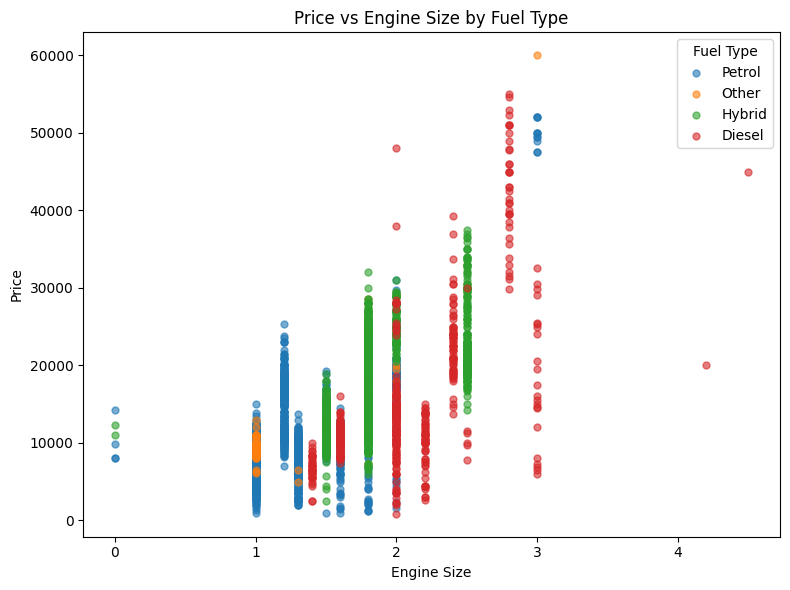

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

for fuel in df_copy["fuelType"].unique():
    subset = df_copy[df_copy["fuelType"] == fuel]
    plt.scatter(
        subset["engineSize"],
        subset["price"],
        s=25,
        alpha=0.6,
        label=fuel
    )

plt.title("Price vs Engine Size by Fuel Type")
plt.xlabel("Engine Size")
plt.ylabel("Price")
plt.legend(title="Fuel Type")
plt.tight_layout()
plt.show()

#### EDA - **Relationships ( Price VS Engine Size) by Transmission**

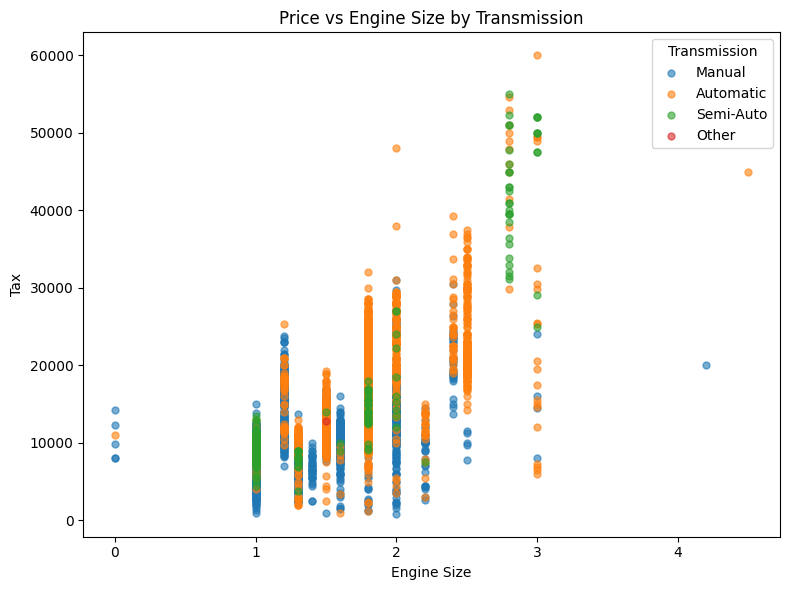

In [ ]:
plt.figure(figsize=(8,6))

for trans in df_copy["transmission"].unique():
    subset = df_copy[df_copy["transmission"] == trans]
    plt.scatter(
        subset["engineSize"],
        subset["price"],
        s=25,
        alpha=0.6,
        label=trans
    )

plt.title("Price vs Engine Size by Transmission")
plt.xlabel("Engine Size")
plt.ylabel("Tax")
plt.legend(title="Transmission")
plt.tight_layout()
plt.show()

#### EDA - **Relationships ( Price VS Engine Size) by Model Type**

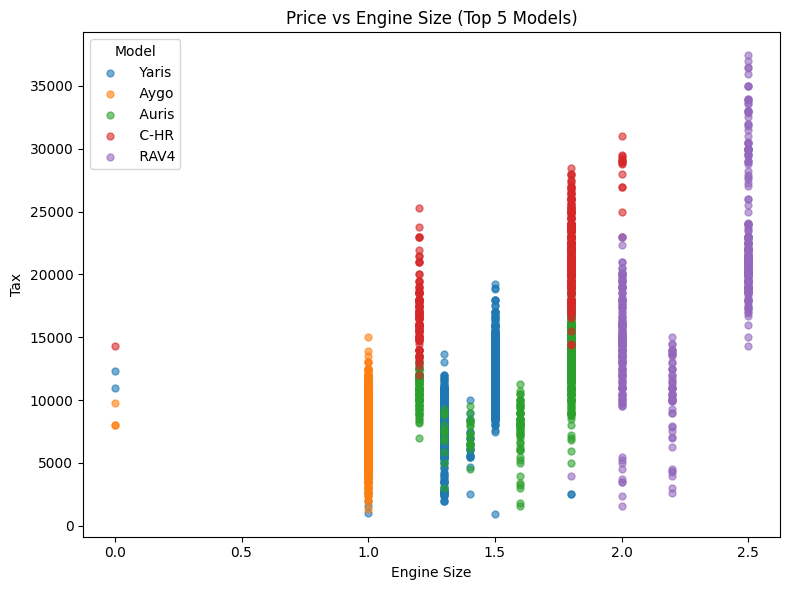

In [ ]:
top_models = df_copy["model"].value_counts().head(5).index

plt.figure(figsize=(8,6))

for model in top_models:
    subset = df_copy[df_copy["model"] == model]
    plt.scatter(
        subset["engineSize"],
        subset["price"],
        s=25,
        alpha=0.6,
        label=model
    )

plt.title("Price vs Engine Size (Top 5 Models)")
plt.xlabel("Engine Size")
plt.ylabel("Tax")
plt.legend(title="Model")
plt.tight_layout()
plt.show()

### EDA - **Relationships ( Price VS MPG)**

### Key Takeways

 1. There appears to be a mild negative relationship between MPG and price.
    → Vehicles with **higher MPG (more fuel-efficient) tend to have lower prices.**

 2. Most vehicles cluster within the mid-MPG range (around 100–200).
    → This likely **represents the mainstream fuel efficiency segment**.

 3. Very high MPG values (>300) are rare and generally associated with lower prices.
    → These may **correspond to highly efficient or specialized vehicles.**

 4. Low MPG vehicles show higher price variability.
    → Some **low-efficiency vehicles are priced high, possibly due to performance or luxury positioning.**

 5. There are several extreme outliers in MPG values.
    → These **may indicate hybrid/electric models or potential data anomalies.**

 6. MPG alone does not strongly explain price.
    → It **likely interacts with engine size, fuel type, and brand.**

 7. Fuel efficiency may act more as a segment indicator (Eco vs Premium)
    **rather than a primary driver of resale price.**

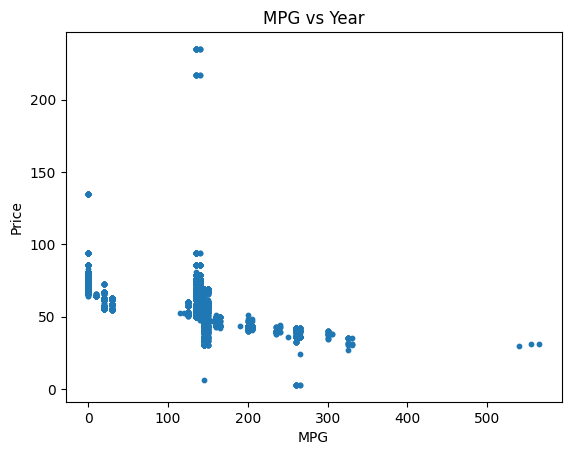

In [ ]:
plt.figure()
plt.scatter(df_copy["tax"], df_copy["mpg"], s=10)
plt.title("MPG vs Year")
plt.xlabel("MPG")
plt.ylabel("Price")
plt.show()

### <h2>Strategic Insights – Price vs MPG Analysis</h2>

<h2>Price vs MPG by Fuel Type</h2>

<table border="1" cellpadding="8" cellspacing="0">
  <tr>
    <th>Observation</th>
    <th>Interpretation</th>
    <th>Intent Signal Strength</th>
    <th>Business Implication</th>
  </tr>

  <tr>
    <td>Weak overall relationship between MPG and price.</td>
    <td>MPG alone does not strongly determine vehicle value.</td>
    <td><b>Weak (Standalone)</b></td>
    <td>Do not rely on MPG as primary pricing predictor.</td>
  </tr>

  <tr>
    <td>Hybrid vehicles cluster at higher MPG and mid-to-high prices.</td>
    <td>MPG reflects eco positioning rather than price tier directly.</td>
    <td><b>Moderate (Segment Signal)</b></td>
    <td>High MPG + Hybrid → Eco desk routing.</td>
  </tr>

  <tr>
    <td>Diesel vehicles show higher prices at moderate MPG levels.</td>
    <td>Price driven more by engine size/model than MPG efficiency.</td>
    <td><b>Moderate (Interaction)</b></td>
    <td>Combine MPG with Fuel Type and Engine Size.</td>
  </tr>

  <tr>
    <td>Very high MPG outliers appear with mixed price levels.</td>
    <td>Possible niche/electric models or data anomalies.</td>
    <td><b>Low</b></td>
    <td>Validate outliers before using MPG in modeling.</td>
  </tr>
</table>

<br/>

<h2>Price vs MPG by Transmission</h2>

<table border="1" cellpadding="8" cellspacing="0">
  <tr>
    <th>Observation</th>
    <th>Interpretation</th>
    <th>Intent Signal Strength</th>
    <th>Business Implication</th>
  </tr>

  <tr>
    <td>Automatic vehicles dominate higher price bands regardless of MPG.</td>
    <td>Transmission effect stronger than MPG.</td>
    <td><b>Strong (Transmission)</b></td>
    <td>Use Transmission over MPG for premium segmentation.</td>
  </tr>

  <tr>
    <td>Manual vehicles cluster in lower price range even at good MPG.</td>
    <td>MPG does not compensate for manual transmission positioning.</td>
    <td><b>Moderate</b></td>
    <td>Manual + High MPG still likely Budget.</td>
  </tr>
</table>

<br/>

<h2>Price vs MPG (Top 5 Models)</h2>

<table border="1" cellpadding="8" cellspacing="0">
  <tr>
    <th>Observation</th>
    <th>Interpretation</th>
    <th>Intent Signal Strength</th>
    <th>Business Implication</th>
  </tr>

  <tr>
    <td>RAV4 maintains high prices at moderate MPG levels.</td>
    <td>Model premium effect outweighs MPG efficiency.</td>
    <td><b>Strong (Model Effect)</b></td>
    <td>Model more important than MPG in valuation.</td>
  </tr>

  <tr>
    <td>Aygo and Yaris show higher MPG but lower price bands.</td>
    <td>Economy positioning despite good fuel efficiency.</td>
    <td><b>Strong (Budget Signal)</b></td>
    <td>High MPG does not equal premium segment.</td>
  </tr>

  <tr>
    <td>C-HR and Auris balance mid MPG and mid-to-high prices.</td>
    <td>Segment-driven pricing beyond fuel efficiency.</td>
    <td><b>Moderate</b></td>
    <td>Combine Model + Year before considering MPG.</td>
  </tr>
</table>

<br/>

<!-- =========================
4) MPG as Intent Signal
========================= -->
<h2>Intent Signal Analysis – MPG</h2>

<table border="1" cellpadding="8" cellspacing="0">
  <tr>
    <th>Intent Type</th>
    <th>Signal Pattern</th>
    <th>Operational Use</th>
  </tr>

  <tr>
    <td><b>High Resale Value Intent</b></td>
    <td>Moderate MPG + Premium Model + Automatic</td>
    <td>Premium routing based on combined signals.</td>
  </tr>

  <tr>
    <td><b>Eco Market Intent</b></td>
    <td>High MPG + Hybrid</td>
    <td>Primary Eco desk candidate.</td>
  </tr>

  <tr>
    <td><b>Budget Market Intent</b></td>
    <td>High MPG + Manual + Small Model</td>
    <td>Budget positioning despite efficiency.</td>
  </tr>
</table>

<br/>

<h3>Analytical Conclusion</h3>
<p>
MPG is a <b>weak standalone predictor of price</b> but acts as a strong <b>segment identifier</b>,
particularly for the Eco category.
Its predictive power increases only when combined with Year, Model, and Transmission.
Compared to Year and Mileage, MPG has lower structural impact on resale value.
</p>

#### EDA - **Relationships ( MPG VS Engine Size) by Fuel Type**

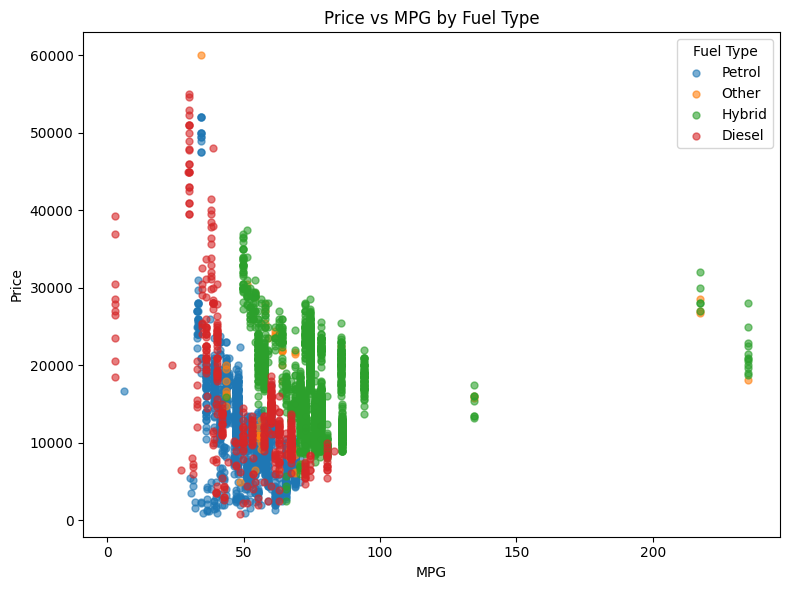

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

for fuel in df_copy["fuelType"].unique():
    subset = df_copy[df_copy["fuelType"] == fuel]
    plt.scatter(
        subset["mpg"],
        subset["price"],
        s=25,
        alpha=0.6,
        label=fuel
    )

plt.title("Price vs MPG by Fuel Type")
plt.xlabel("MPG")
plt.ylabel("Price")
plt.legend(title="Fuel Type")
plt.tight_layout()
plt.show()

#### EDA - **Relationships ( Price VS Engine Size) by Transmission**

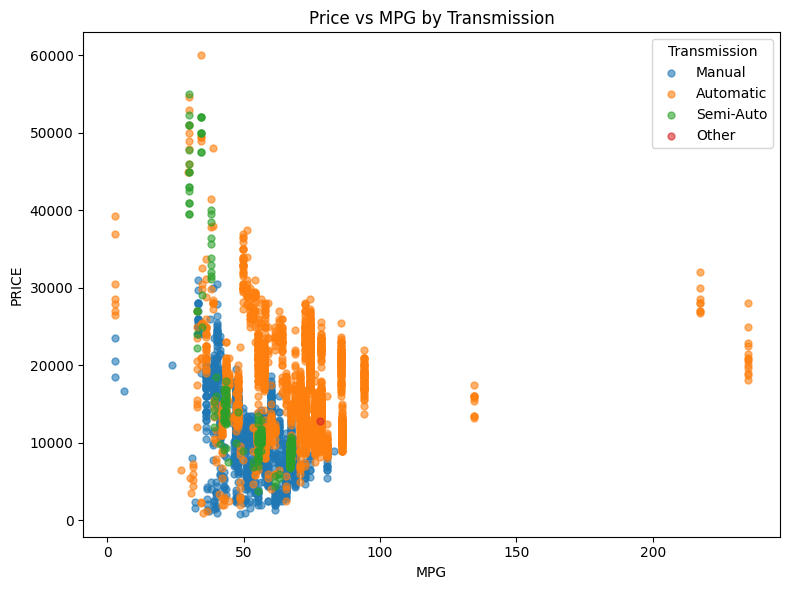

In [ ]:
plt.figure(figsize=(8,6))

for trans in df_copy["transmission"].unique():
    subset = df_copy[df_copy["transmission"] == trans]
    plt.scatter(
        subset["mpg"],
        subset["price"],
        s=25,
        alpha=0.6,
        label=trans
    )

plt.title("Price vs MPG by Transmission")
plt.xlabel("MPG")
plt.ylabel("PRICE")
plt.legend(title="Transmission")
plt.tight_layout()
plt.show()

#### EDA - **Relationships ( Price VS Engine Size) by Model Type**

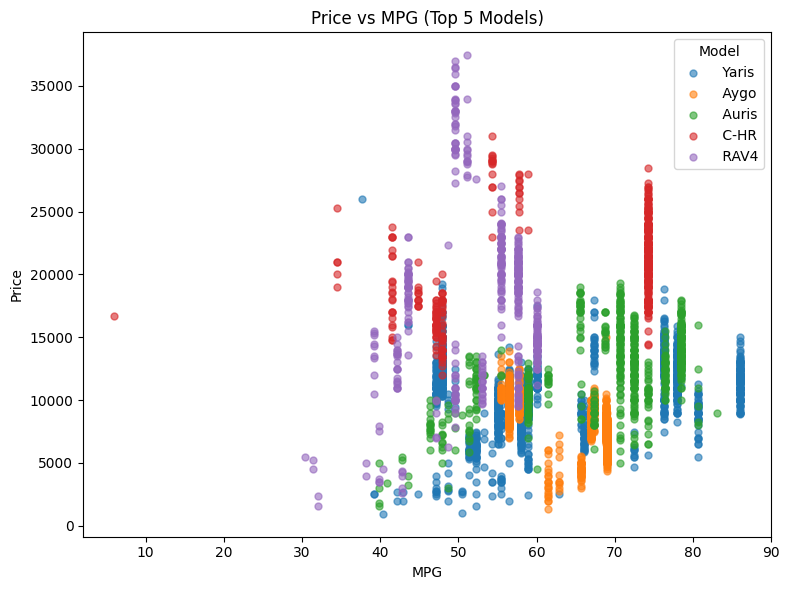

In [ ]:
top_models = df_copy["model"].value_counts().head(5).index

plt.figure(figsize=(8,6))

for model in top_models:
    subset = df_copy[df_copy["model"] == model]
    plt.scatter(
        subset["mpg"],
        subset["price"],
        s=25,
        alpha=0.6,
        label=model
    )

plt.title("Price vs MPG (Top 5 Models)")
plt.xlabel("MPG")
plt.ylabel("Price")
plt.legend(title="Model")
plt.tight_layout()
plt.show()

<h3>Summary Key Takeaways</h3>

<p><strong>Base Knowledge on Numerical Features</strong></p>

<table border="1" cellpadding="8" cellspacing="0">
  <thead>
    <tr>
      <th>Variable</th>
      <th>Strength</th>
      <th>Shape</th>
      <th>Business Meaning</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td>Year</td>
      <td>Strong positive</td>
      <td>Linear accelerating</td>
      <td>Strong liquidity driver</td>
    </tr>
    <tr>
      <td>Mileage</td>
      <td>Strong negative</td>
      <td>Non-linear depreciation</td>
      <td>Strong liquidity driver</td>
    </tr>
    <tr>
      <td>Engine Size</td>
      <td>Strong positive</td>
      <td>Segment-based</td>
      <td>Segment indicator</td>
    </tr>
    <tr>
      <td>Tax</td>
      <td>Moderate</td>
      <td>Interacting</td>
      <td>Secondary factor</td>
    </tr>
    <tr>
      <td>MPG</td>
      <td>Weak</td>
      <td>Mild</td>
      <td>Segment indicator</td>
    </tr>
  </tbody>
</table>

## Answering Goal

### Goal 1
> `Identify which specific car features (e.g., Year, Mileage, Fuel Type) act as the strongest "intent signals" for a high resale value or a fast sale.`



<h2>Conclusion & Methodological Rationale – Strongest “Intent Signals” for High Resale Value vs Fast Sale</h2>

<p>
This analysis identifies which car features act as the strongest <b>intent signals</b> for either
<b>high resale value</b> or <b>fast sale potential</b>.
The approach combines structured visual EDA with interaction analysis to distinguish between:
</p>

<ul>
  <li><b>Structural drivers</b> → features that consistently shift the overall price band</li>
  <li><b>Segment indicators</b> → features that refine positioning within an existing price band</li>
</ul>

<hr/>

<h3>1) Overall Intent Signal Strength Ranking</h3>

<table border="1" cellpadding="8" cellspacing="0">
  <tr>
    <th>Rank</th>
    <th>Feature</th>
    <th>Signal Type</th>
    <th>Why It Is Strong (Visual Evidence)</th>
    <th>Implication</th>
  </tr>

  <tr>
    <td><b>1</b></td>
    <td><b>Year</b></td>
    <td>Structural Driver</td>
    <td>Clear, consistent upward trend across all segments; establishes base valuation band.</td>
    <td>Primary predictor of resale value.</td>
  </tr>

  <tr>
    <td><b>2</b></td>
    <td><b>Mileage</b></td>
    <td>Structural Driver</td>
    <td>Strong negative relationship with price across fuel types, transmissions, and models.</td>
    <td>Core depreciation indicator.</td>
  </tr>

  <tr>
    <td><b>3</b></td>
    <td><b>Model</b></td>
    <td>Segment Amplifier</td>
    <td>Clear tier separation (e.g., RAV4 highest band; Aygo/Yaris lowest).</td>
    <td>Strong premium vs budget segmentation signal.</td>
  </tr>

  <tr>
    <td><b>4</b></td>
    <td><b>Transmission</b></td>
    <td>Segment Amplifier</td>
    <td>Automatic consistently priced higher than Manual within similar conditions.</td>
    <td>Premium positioning enhancer.</td>
  </tr>

  <tr>
    <td><b>5</b></td>
    <td><b>Fuel Type</b></td>
    <td>Segment Identifier</td>
    <td>Diesel and Hybrid show higher ceilings; Petrol dominates lower bands.</td>
    <td>Premium vs Eco differentiation.</td>
  </tr>

  <tr>
    <td><b>6</b></td>
    <td><b>Engine Size</b></td>
    <td>Segment Amplifier</td>
    <td>Positive price relationship; strongest when combined with Model & Transmission.</td>
    <td>Premium reinforcement feature.</td>
  </tr>

  <tr>
    <td><b>7</b></td>
    <td><b>Tax</b></td>
    <td>Banded Segment Signal</td>
    <td>Clustered brackets rather than continuous spread.</td>
    <td>Useful categorically, not as linear predictor.</td>
  </tr>

  <tr>
    <td><b>8</b></td>
    <td><b>MPG</b></td>
    <td>Weak Standalone / Eco Signal</td>
    <td>No strong monotonic relationship with price.</td>
    <td>Mainly identifies eco positioning.</td>
  </tr>
</table>

<hr/>

<h3>2) What Signals High Resale Value?</h3>

<table border="1" cellpadding="8" cellspacing="0">
  <tr>
    <th>Primary Drivers</th>
    <th>Refining Signals</th>
    <th>Typical Pattern</th>
  </tr>

  <tr>
    <td><b>Year + Mileage</b></td>
    <td>Model + Transmission + Fuel Type + Engine Size</td>
    <td>
      <b>Newer Year (2015+)</b> + <b>Low Mileage (&lt;30k)</b> <br/>
      + Premium Model (RAV4 / C-HR) <br/>
      + Automatic/Semi-Auto <br/>
      + Diesel/Hybrid <br/>
      + Engine Size &gt; 2.0
    </td>
  </tr>
</table>

<p>
<b>Rationale:</b> Year establishes structural value. Mileage determines depreciation.
Model and Transmission create the largest segmentation lift inside the same band.
Other features amplify but rarely override Year–Mileage.
</p>

<hr/>

<h3>3) What Signals Fast Sale?</h3>

<table border="1" cellpadding="8" cellspacing="0">
  <tr>
    <th>Core Pattern</th>
    <th>Reasoning</th>
  </tr>

  <tr>
    <td>
      <b>Mid-age (2014–2017)</b> + <b>Mid Mileage (30k–70k)</b>
    </td>
    <td>
      Balances affordability and recency → wider buyer pool → higher liquidity.
    </td>
  </tr>
</table>

<p>
<b>Rationale:</b> Fast sale is not driven by maximum price.
It is driven by demand accessibility.
Extremely premium vehicles may retain value but have smaller buyer pools.
Mid-range Year–Mileage combinations create optimal liquidity.
</p>

<hr/>

<h3>4) Methodological Justification</h3>

<table border="1" cellpadding="8" cellspacing="0">
  <tr>
    <th>Method Choice</th>
    <th>Why It Was Used</th>
  </tr>

  <tr>
    <td><b>Scatter Plots</b></td>
    <td>To detect monotonic trends, dispersion, clustering, and non-linear patterns.</td>
  </tr>

  <tr>
    <td><b>Category Overlay (Fuel / Transmission / Model)</b></td>
    <td>To identify interaction effects and determine whether signals are universal or segment-specific.</td>
  </tr>

  <tr>
    <td><b>Structural vs Segment Classification</b></td>
    <td>Prevents overestimating weak predictors (e.g., MPG) and clarifies modeling hierarchy.</td>
  </tr>

  <tr>
    <td><b>Tax Treated as Banded</b></td>
    <td>Visual clustering suggests bracket-based system; modeling as continuous would mislead.</td>
  </tr>

  <tr>
    <td><b>Sweet-Spot Definition for Fast Sale</b></td>
    <td>Derived from market behavior logic: liquidity comes from accessibility, not peak price.</td>
  </tr>
</table>

<hr/>

<h3>Final Strategic Conclusion</h3>

<p>
The strongest intent signals for <b>high resale value</b> are:
</p>

<ul>
  <li><b>Year (Primary Structural Driver)</b></li>
  <li><b>Mileage (Primary Depreciation Signal)</b></li>
  <li><b>Model & Transmission (Major Segmentation Amplifiers)</b></li>
</ul>

<p>
For <b>fast sale potential</b>, the most influential pattern is:
</p>

<ul>
  <li><b>Mid-range Year + Mid-range Mileage</b></li>
  <li>Combined with competitive positioning inside its segment</li>
</ul>

<p>
In summary, <b>Year and Mileage form the structural backbone of valuation</b>,
while Model, Transmission, Fuel Type, and Engine Size refine premium positioning.
Tax and MPG are secondary features that improve segmentation but do not drive price independently.

Strongest intent signals for <b>high resale value are Year (dominant upward trend) and Mileage (clear depreciation effect), while Model, Transmission, and Fuel Type act as key segment amplifiers that lift a vehicle into premium price bands</b>.

Fast sale intent signals (without days-on-market data) are best approximated by mid-age Year + mid Mileage (liquidity sweet spot), mass-market models, and mainstream specs (Petrol/Automatic, mid tax/engine size) which maximize buyer pool and affordability.
</p>

### Goal 2
> `If you were a B2B car wholesaler using this dataset, what 3 external data points are missing that would help you predict price more accurately?`



<h2>3 Missing External Data Points for Better Price Prediction (B2B Wholesaler)</h2>

<p>
Based on the visual insights, <b>Year</b> and <b>Mileage</b> act as the strongest structural drivers of price,
while <b>Model</b> and <b>Transmission</b> refine premium vs budget positioning.
However, the dataset is mainly “vehicle-spec” focused and lacks three critical external signals:
<b>(1) market demand/liquidity</b>, <b>(2) vehicle condition risk</b>, and <b>(3) macro/regional context</b>.
These missing inputs would reduce unexplained variance and improve both valuation accuracy and sell-through forecasting.
</p>

<table border="1" cellpadding="8" cellspacing="0">
  <tr>
    <th>External Data Point (Missing)</th>
    <th>Examples of What to Collect</th>
    <th>Why It Improves Price Prediction (Rationale)</th>
    <th>Wholesaler Impact</th>
  </tr>

  <tr>
    <td><b>1) Real-Time Market Demand / Liquidity Index</b></td>
    <td>
      Days on Market (DOM) by model/trim/year;<br/>
      current listing volume (supply);<br/>
      auction clearance rate;<br/>
      marketplace search volume trend
    </td>
    <td>
      Price is not only “intrinsic value” (Year/Mileage) but also <b>market willingness to pay</b>.
      Two identical cars can price differently when a model is oversupplied or trending.
      This directly supports <b>fast sale</b> prediction and price elasticity adjustments.
    </td>
    <td>
      Better buy decisions, faster inventory turnover, lower holding costs, fewer slow-moving stocks.
    </td>
  </tr>

  <tr>
    <td><b>2) Vehicle Condition & Accident / Service History Score</b></td>
    <td>
      accident history (severity);<br/>
      insurance write-off / salvage flags;<br/>
      full service history (yes/no);<br/>
      number of previous owners;<br/>
      inspection/auction grade (A/B/C/D)
    </td>
    <td>
      Visuals show wide price dispersion even within the same Year and Mileage ranges.
      A major source of that variance is <b>condition and risk</b>.
      Adding condition history reduces prediction error and helps separate true “gems” from high-risk units.
    </td>
    <td>
      Lower refurbishment surprises, better margin protection, more accurate valuation and risk screening.
    </td>
  </tr>

  <tr>
    <td><b>3) Regional + Macro Factors (Demand Environment)</b></td>
    <td>
      regional fuel prices;<br/>
      interest rates / auto-loan rates;<br/>
      inflation;<br/>
      regional income / affordability index;<br/>
      city-level demand differences
    </td>
    <td>
      Fuel and financing conditions can shift demand between segments (e.g., Hybrid demand increases when fuel prices rise).
      These factors explain <b>time-based pricing shifts</b> that are not captured by vehicle specs alone.
      They enable forward-looking pricing and procurement strategies.
    </td>
    <td>
      Improved forecasting, timing purchases before market shifts, better regional pricing strategy.
    </td>
  </tr>
</table>

<br/>

<h3>Conclusion</h3>
<p>
For a B2B wholesaler, the best external additions are:
<b>(1) demand/liquidity indicators</b>, <b>(2) condition/history risk signals</b>, and <b>(3) macro/regional context</b>.
Together, these cover the three biggest missing dimensions: <b>market willingness to pay</b>, <b>asset quality</b>, and <b>economic environment</b>.
</p>

### Goal 3
> `We have three sales desks: Budget, Premium, and Eco. Based on this dataset, define the technical logic/filters to automatically route a new car listing to the correct desk.`

<h2>Desk Routing Logic – Thinking Flowchart (Explainable Rules)</h2>

<p>
This flowchart documents the reasoning used to route each new car listing into one of three desks:
<b>Eco</b>, <b>Premium</b>, or <b>Budget</b>. The logic is intentionally explainable and aligned with
the strongest intent signals found in Q1:
<b>Year &amp; Mileage</b> as structural drivers, with <b>Model &amp; Transmission</b> as amplifiers,
and <b>Fuel Type / MPG</b> as Eco identifiers.
</p>

<hr/>

<h3>Legend</h3>
<ul>
  <li><b>Structural drivers:</b> Year, Mileage (strongest baseline signals)</li>
  <li><b>Amplifiers:</b> Model tier (premium/budget), Transmission (Automatic/Semi-Auto), Fuel (Diesel/Hybrid), EngineSize, Tax</li>
  <li><b>Eco identifiers:</b> Hybrid fuel type and/or high MPG (top quartile), with guardrails to avoid misrouting old/high-mileage units</li>
</ul>

<hr/>

<h3>Flowchart (Decision Steps)</h3>

<table border="1" cellpadding="10" cellspacing="0" style="border-collapse:collapse; width:100%; table-layout:fixed;">
  <colgroup>
    <col style="width:20%;">
    <col style="width:40%;">
    <col style="width:40%;">
  </colgroup>

  <tr style="background:#f5f5f5;">
    <th style="text-align:left; vertical-align:top;">Step</th>
    <th style="text-align:left; vertical-align:top;">Decision / Condition</th>
    <th style="text-align:left; vertical-align:top;">Action / Output</th>
  </tr>

  <!-- Step 0 -->
  <tr>
    <td style="vertical-align:top; white-space:normal; word-break:break-word; overflow-wrap:anywhere;">
      <b>Pre-check</b>
    </td>
    <td style="vertical-align:top; white-space:normal; word-break:break-word; overflow-wrap:anywhere;">
      Standardize text fields: fuelType, transmission, model (lowercase, trimmed).<br/>
      Compute adaptive thresholds from percentiles (price, year, mileage, mpg, engineSize, tax).
    </td>
    <td style="vertical-align:top; white-space:normal; word-break:break-word; overflow-wrap:anywhere;">
      Proceed to routing decisions using dataset-driven cutoffs (not hardcoded).
    </td>
  </tr>

  <!-- Step 1: ECO -->
  <tr>
    <td style="vertical-align:top; white-space:normal; word-break:break-word; overflow-wrap:anywhere;">
      <b>ECO check (Priority 1)</b>
    </td>
    <td style="vertical-align:top; white-space:normal; word-break:break-word; overflow-wrap:anywhere;">
      <b>Eco signal?</b><br/>
      - Fuel Type = Hybrid<br/>
      OR<br/>
      - MPG ≥ 75th percentile<br/><br/>
      <b>Quality guardrails?</b><br/>
      - Year ≥ 30th percentile<br/>
      AND<br/>
      - Mileage ≤ 70th percentile
    </td>
    <td style="vertical-align:top; white-space:normal; word-break:break-word; overflow-wrap:anywhere;">
      If both Eco signal + guardrails are satisfied → <b>Route to ECO desk</b>.<br/><br/>
      <i>Rationale:</i> MPG is weak standalone, but strong for Eco positioning when paired with Hybrid.
      Guardrails prevent misrouting old/high-mileage cars as Eco.
    </td>
  </tr>

  <!-- Step 2: PREMIUM -->
  <tr>
    <td style="vertical-align:top; white-space:normal; word-break:break-word; overflow-wrap:anywhere;">
      <b>PREMIUM check (Priority 2)</b>
    </td>
    <td style="vertical-align:top; white-space:normal; word-break:break-word; overflow-wrap:anywhere;">
      <b>Structural premium?</b><br/>
      - Price ≥ 70th percentile<br/>
      AND Year ≥ 70th percentile<br/>
      AND Mileage ≤ 30th percentile<br/><br/>
      <b>OR</b><br/>
      <b>Medium structural + amplifiers:</b><br/>
      - Price ≥ 70th percentile<br/>
      AND Year ≥ 70th percentile<br/>
      AND Mileage ≤ 50th percentile<br/>
      AND Amplifier score ≥ 2
      <br/><br/>
      <b>Amplifiers include:</b><br/>
      - Premium model tier (top 30% by median model price)<br/>
      - Automatic/Semi-Auto transmission<br/>
      - Fuel = Diesel or Hybrid<br/>
      - EngineSize ≥ 70th percentile<br/>
      - Tax ≥ 70th percentile
    </td>
    <td style="vertical-align:top; white-space:normal; word-break:break-word; overflow-wrap:anywhere;">
      If structural premium is met → <b>Route to PREMIUM desk</b>.<br/>
      Else if medium structural + amplifiers ≥ 2 → <b>Route to PREMIUM desk</b>.<br/><br/>
      <i>Rationale:</i> Year + Mileage are the strongest valuation drivers.
      Model and Transmission add the biggest lift within the same year/mileage band.
      Fuel/Engine/Tax refine premium positioning.
    </td>
  </tr>

  <!-- Step 3: BUDGET -->
  <tr>
    <td style="vertical-align:top; white-space:normal; word-break:break-word; overflow-wrap:anywhere;">
      <b>BUDGET check (Priority 3)</b>
    </td>
    <td style="vertical-align:top; white-space:normal; word-break:break-word; overflow-wrap:anywhere;">
      <b>Structural budget?</b><br/>
      - Price ≤ 35th percentile<br/>
      OR Year ≤ 30th percentile<br/>
      OR Mileage ≥ 70th percentile<br/><br/>
      <b>OR</b><br/>
      <b>Reinforced budget:</b><br/>
      - Price ≤ median price<br/>
      AND Budget amplifier score ≥ 2<br/><br/>
      <b>Budget amplifiers include:</b><br/>
      - Budget model tier (bottom 30% by median model price)<br/>
      - Manual transmission<br/>
      - Fuel = Petrol
    </td>
    <td style="vertical-align:top; white-space:normal; word-break:break-word; overflow-wrap:anywhere;">
      If structural budget is met → <b>Route to BUDGET desk</b>.<br/>
      Else if reinforced budget is met → <b>Route to BUDGET desk</b>.<br/><br/>
      <i>Rationale:</i> Budget routing is driven by low price band, older year, or high mileage.
      Manual/entry models/petrol strengthen budget positioning.
    </td>
  </tr>

  <!-- Step 4: Tie-break -->
  <tr>
    <td style="vertical-align:top; white-space:normal; word-break:break-word; overflow-wrap:anywhere;">
      <b>Tie-break (Fast Sale Sweet Spot)</b>
    </td>
    <td style="vertical-align:top; white-space:normal; word-break:break-word; overflow-wrap:anywhere;">
      If not clearly Eco or Premium:<br/>
      - Year in mid-range (30th–70th percentile)<br/>
      AND<br/>
      - Mileage in mid-range (30th–70th percentile)
    </td>
    <td style="vertical-align:top; white-space:normal; word-break:break-word; overflow-wrap:anywhere;">
      Route to <b>BUDGET desk</b> by default (mass-market handling).<br/><br/>
      <i>Rationale:</i> “Fast sale” is often driven by broad demand accessibility (mid-year + mid-mileage),
      and Budget desk typically aligns with higher liquidity segments.
      (If the business supports it, this could be a separate “Fast Sale” queue.)
    </td>
  </tr>

  <!-- Step 5 -->
  <tr>
    <td style="vertical-align:top; white-space:normal; word-break:break-word; overflow-wrap:anywhere;">
      <b>Default fallback</b>
    </td>
    <td style="vertical-align:top; white-space:normal; word-break:break-word; overflow-wrap:anywhere;">
      If none of the above rules match due to missing values or edge cases.
    </td>
    <td style="vertical-align:top; white-space:normal; word-break:break-word; overflow-wrap:anywhere;">
      Route to <b>BUDGET desk</b> (safest and broadest desk).
    </td>
  </tr>
</table>

<br/>

<h3>Key Design Principles (Why This Flow Works)</h3>
<ul>
  <li><b>Explainable:</b> Every decision corresponds to an observable pattern in the EDA.</li>
  <li><b>Adaptive:</b> Uses percentile thresholds so it remains valid if the dataset distribution shifts.</li>
  <li><b>Interaction-aware:</b> Premium assignment uses amplifiers because price dispersion increases for newer cars.</li>
  <li><b>Eco-safe:</b> Guardrails prevent incorrectly labeling old/high-mileage cars as Eco just because MPG is high.</li>
</ul>

In [125]:
# Prepare a clean copy
df_routing = df.copy()

for c in ["fuelType", "transmission", "model"]:
    if c in df_routing.columns:
        df_routing[c] = df_routing[c].astype(str).str.strip().str.lower()

In [126]:
# Adaptive thresholds (quantile-based)
# Price thresholds
p35 = df_routing["price"].quantile(0.35)
p70 = df_routing["price"].quantile(0.70)

# Year thresholds (newness)
y30 = df_routing["year"].quantile(0.30)
y70 = df_routing["year"].quantile(0.70)

# Mileage thresholds (usage)
m30 = df_routing["mileage"].quantile(0.30)
m50 = df_routing["mileage"].quantile(0.50)
m70 = df_routing["mileage"].quantile(0.70)

# MPG (Eco indicator, but weak standalone)
mpg75 = df_routing["mpg"].quantile(0.75) if "mpg" in df_routing.columns else None

# Engine size & tax (segment refiners)
eng70 = df_routing["engineSize"].quantile(0.70) if "engineSize" in df_routing.columns else None
tax70 = df_routing["tax"].quantile(0.70) if "tax" in df_routing.columns else None

p35, p70, y30, y70, m30, m50, m70

(np.float64(9295.0),
 np.float64(13688.499999999995),
 np.float64(2016.0),
 np.float64(2018.0),
 np.float64(11000.0),
 np.float64(18513.0),
 np.float64(28023.0))

In [127]:
# Data-driven model tiers (avoid hardcoded lists)
# Rationale:
# - Model is a strong segmentation signal in visuals
# - Derive premium/budget models from median price per model

model_col = "model" if "model" in df_routing.columns else None
premium_models, budget_models = set(), set()

if model_col:
    model_median_price = df_routing.groupby(model_col)["price"].median().sort_values(ascending=False)

    top_n = max(1, int(np.ceil(len(model_median_price) * 0.30)))
    bottom_n = max(1, int(np.ceil(len(model_median_price) * 0.30)))

    premium_models = set(model_median_price.head(top_n).index)
    budget_models = set(model_median_price.tail(bottom_n).index)

premium_models, budget_models

({'camry', 'corolla', 'hilux', 'land cruiser', 'proace verso', 'supra'},
 {'avensis', 'aygo', 'iq', 'urban cruiser', 'verso-s', 'yaris'})

In [128]:
# Helper functions
def safe_get(row, col, default=None):
    return row[col] if col in row.index else default

def is_auto(trans):
    return trans in ["automatic", "semi-auto", "semiauto", "semi auto"]

In [129]:
# Desk routing function (Eco -> Premium -> Budget)
def route_desk(row):
    fuel = safe_get(row, "fuelType", "")
    trans = safe_get(row, "transmission", "")
    model = safe_get(row, "model", "")

    price = safe_get(row, "price", np.nan)
    year = safe_get(row, "year", np.nan)
    mileage = safe_get(row, "mileage", np.nan)

    mpg = safe_get(row, "mpg", np.nan)
    eng = safe_get(row, "engineSize", np.nan)
    tax = safe_get(row, "tax", np.nan)

    # ------------------------------------------
    # A) ECO desk (Eco positioning, guardrails)
    # ------------------------------------------
    # Rationale:
    # MPG is weak standalone, strongest for Eco when paired with Hybrid.
    eco_signal = (
        (fuel == "hybrid") or
        (mpg75 is not None and pd.notna(mpg) and mpg >= mpg75)
    )

    # Guardrails: avoid misrouting very old / very high mileage units as Eco
    eco_quality_guard = (
        (pd.notna(year) and year >= y30) and
        (pd.notna(mileage) and mileage <= m70)
    )

    if eco_signal and eco_quality_guard:
        return "Eco"

    # ------------------------------------------
    # B) PREMIUM desk (structural + amplifiers)
    # ------------------------------------------
    # Structural drivers: Year, Mileage (strongest intent signals)
    premium_structural = (
        pd.notna(price) and pd.notna(year) and pd.notna(mileage) and
        (price >= p70) and (year >= y70) and (mileage <= m30)
    )

    # Amplifiers: Model, Transmission, Fuel, EngineSize, Tax
    premium_amplifiers = 0
    if model_col and model in premium_models:
        premium_amplifiers += 1
    if is_auto(trans):
        premium_amplifiers += 1
    if fuel in ["diesel", "hybrid"]:
        premium_amplifiers += 1
    if eng70 is not None and pd.notna(eng) and eng >= eng70:
        premium_amplifiers += 1
    if tax70 is not None and pd.notna(tax) and tax >= tax70:
        premium_amplifiers += 1

    # Allow Premium if medium structural + strong amplifiers
    premium_medium_structural = (
        pd.notna(price) and pd.notna(year) and pd.notna(mileage) and
        (price >= p70) and (year >= y70) and (mileage <= m50)
    )

    if premium_structural:
        return "Premium"
    if premium_medium_structural and premium_amplifiers >= 2:
        return "Premium"

    # ------------------------------------------
    # C) BUDGET desk (lower bands + reinforcers)
    # ------------------------------------------
    budget_structural = (
        (pd.notna(price) and price <= p35) or
        (pd.notna(year) and year <= y30) or
        (pd.notna(mileage) and mileage >= m70)
    )

    budget_amplifiers = 0
    if model_col and model in budget_models:
        budget_amplifiers += 1
    if trans == "manual":
        budget_amplifiers += 1
    if fuel == "petrol":
        budget_amplifiers += 1

    if budget_structural:
        return "Budget"
    if budget_amplifiers >= 2 and (pd.notna(price) and price <= df_routing["price"].median()):
        return "Budget"

    # ------------------------------------------
    # D) Fast-sale sweet spot (tie-break)
    # ------------------------------------------
    # Rationale:
    # Fast sale often sits at mid-year + mid-mileage (broad buyer pool).
    fast_sale_sweet_spot = (
        pd.notna(year) and pd.notna(mileage) and
        (year >= y30) and (year <= y70) and
        (mileage >= m30) and (mileage <= m70)
    )

    if fast_sale_sweet_spot:
        return "Budget"

    return "Budget"

In [130]:
# Apply & Validate
df_routing["desk"] = df_routing.apply(route_desk, axis=1)
df_routing["desk"].value_counts()

,count
desk,
Budget,4820
Eco,1611
Premium,307


### Goal 4
> `Find "Underpriced Gems", i.e. cars priced significantly below the market average for their year/model.`

In [131]:
df_gems = df.copy()

# Predict Expected Market Price (Model)

df_gems["expected_price"] = pipe.predict(df_gems.drop(columns=["price"]))

df_gems["residual"] = df_gems["price"] - df_gems["expected_price"]

df_gems["discount_pct"] = (
    (df_gems["expected_price"] - df_gems["price"])
    / df_gems["expected_price"]
)

df_gems["discount_pct"] = df_gems["discount_pct"].replace([np.inf, -np.inf], np.nan)

NameError: name 'pipe' is not defined